# [GGUF (Georgi Gerganov Unified Format)](https://github.com/unslothai/unsloth?tab=readme-ov-file)
- GGUF 포맷은 Georgi Gerganov에 의해 개발된 딥러닝 모델 저장용 단일 파일 포맷입니다.
- 이 포맷은 메타데이터와 텐서 데이터를 저장하며, 다양한 양자화를 지원하여 모델의 크기를 줄이고 추론 속도를 높입니다.
- GGUF는 주로 GGML 라이브러리 기반 런타임에서 사용되며, CPU에서도 실행 가능하여 큰 유연성과 확장성을 제공합니다.

## [GGML이란?](https://www.ibm.com/kr-ko/think/topics/gguf-versus-ggml)
- 개발자 게오르기 게르가노프(Georgi Gerganov)가 만든 `GGML`은 `GGUF` 바로 이전의 파일 형식입니다.
- `GGML`은 다양한 하드웨어 플랫폼에서 고성능을 발휘하도록 설계된 텐서 라이브러리였습니다.
- `GGML`은 표준 하드웨어에서 대규모 언어 모델에 액세스할 수 있도록 하기 위한 초기 노력이었습니다. 그러나 유연성과 확장성 측면에서 제한적이었습니다.

`GGUF`는 `GGML` 제한 사항을 해결하고 이전 모델과의 호환성을 유지하면서 새로운 기능을 추가할 수 있게 합니다. `GGUF`는 주요 변경 사항을 제거하여 최신 버전으로의 전환이 용이하게 하고 다양한 모델을 지원하는 포괄적인 솔루션입니다.

## [GGUF 파일에는 두 가지가 기록된다.](https://bitwise-life.tistory.com/4)
1. 모델의 Weight Tensor 값과 텐서 정보
  - Tensor 의 이름
  - Tensor 의 차원 수
  - Tensor 의 Shape
  - Tensor 의 데이터 타입
  - Tensor 데이터가 위치한 Offset
2. Key-Value 형식의 메타데이터
  - Key는 ASCII 문자와 '.' 으로 계층을 표현한다.
    - 다음처럼 쓸 수 있다. llama.attention.head_count_kv
  - 먼저 모델의 세부 정보들이 포함되어야한다. 예를 들어
    - 입력 토큰 길이 (context length)
    - 임베딩 크기 (embedding length)
    - 피드 포워드 길이 (feed forward length)
  - 여기에 추가로 Tokenizer 의 정보도 단일 파일에 포함되어야한다.
    - bos token id
    - eos token id
    - uknown token id
    - seperate token id
    - padding token id
    - Vocab file


## GGUF 장점
- `단일 파일 구조`: 모델을 하나의 파일로 쉽게 공유할 수 있습니다. 이는 모델의 배포와 사용을 간편하게 만듭니다.
- `메타데이터와 텐서 데이터`: 파일 내에 모델의 가중치(weight) 텐서 값들과 메타데이터가 Key-Value 형식으로 저장됩니다. 메타데이터는 모델의 구조, 버전, 텐서 개수 등을 포함합니다.
- `다양한 양자화 지원`: GGUF는 16-bit 부동 소수점(floating point)뿐만 아니라 8-bit, 6-bit, 5-bit, 4-bit, 3-bit, 그리고 2-bit까지의 다양한 양자화된 텐서 타입을 지원합니다. 이는 모델을 더 작게 만들어 추론 속도를 높이고, 메모리 사용을 줄이는 데 유용합니다.

# [예제](https://docs.unsloth.ai/get-started/unsloth-notebooks)

- [HuggingFace API Key](https://huggingface.co/settings/tokens)

In [1]:
from dotenv import load_dotenv

# .env 파일에 기록된 환경 변수를 시스템으로 불러옵니다.
load_dotenv() 

True

In [2]:
import sys
from tqdm import tqdm as std_tqdm

# 주피터 위젯 버전의 tqdm을 일반 텍스트 버전으로 덮어씌웁니다.
import tqdm.notebook as tqdm_notebook
tqdm_notebook.tqdm = std_tqdm

## Download Model

In [7]:
from huggingface_hub import snapshot_download

model_id = "good593/unsloth-gemma3-1b-finetune-nutrition"
local_dir = "./models/gemma3"

snapshot_download(
    repo_id=model_id,
    local_dir=local_dir
)

'/workspace/lectures/models/gemma3'

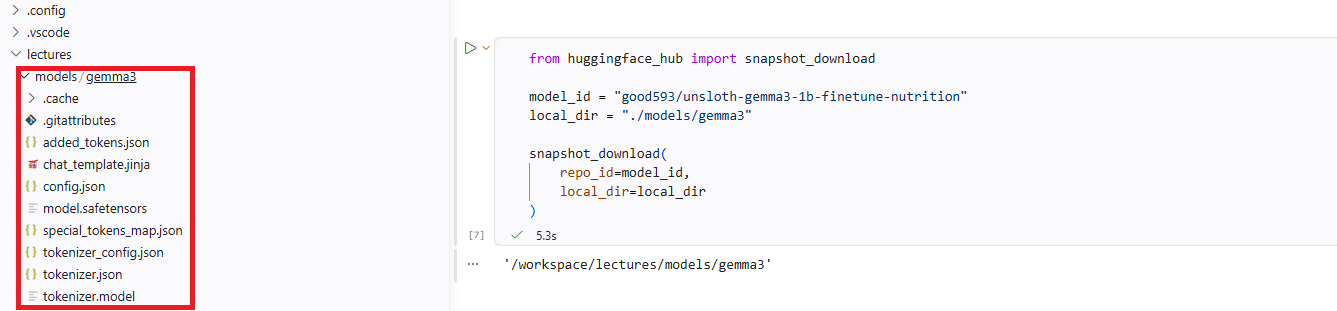

### Load Model

In [8]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM

peft_tokenizer = AutoTokenizer.from_pretrained(local_dir)

peft_model = AutoModelForCausalLM.from_pretrained(
    local_dir,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True
)
print("Fine-tuned 모델 로드 완료")

The tokenizer you are loading from './models/gemma3' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Fine-tuned 모델 로드 완료


### Inference

In [9]:
import torch

# 답변 생성 함수
def generate_answer(question, model, tokenizer, max_length=512):
    """모델을 사용하여 질문에 대한 답변 생성"""
    # 프롬프트 구성
    prompt = f"질문: {question}\n\n답변:"
    
    # 토큰화
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # 답변 생성
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 디코딩
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # 답변 부분만 추출
    if "답변:" in full_text:
        answer = full_text.split("답변:")[-1].strip()
    else:
        answer = full_text.replace(prompt, "").strip()
    
    return answer

print("답변 생성 함수 준비 완료")

답변 생성 함수 준비 완료


In [10]:
answer = generate_answer("허니 햄버거 병이란 무엇인가요?", peft_model, peft_tokenizer) 

print(answer)

허니 햄버거 병은 일반적으로 병이 부실하고 뚜껑이 닫힌 채로 사용되는 병으로, 병 내부의 햄버거를 담기 위해 사용됩니다. 이 병은 일반적인 병과 다르며, 뚜껑을 열고 병을 돌려 햄버거를 담는 방식이 다릅니다.


## Save GGUF Model

In [14]:
import os
import subprocess
import sys

In [11]:
# ========== 설정 ==========
MODEL_DIR = "./models/gemma3"               # 모델 저장 경로
OUTPUT_GGUF = "./unsloth-gemma3-1b-finetune-nutrition.gguf"          # 변환 결과
QUANTIZED_GGUF = "./unsloth-gemma3-1b-finetune-nutrition_q4km.gguf" # 양자화 결과
QUANT_TYPE = "Q4_K_M"                 # 양자화 방식
LLAMA_CPP_DIR = "/opt/llama.cpp"         # llama.cpp 경로
# ==========================

### GGUF 변환

In [12]:
def convert_to_gguf():
    print("GGUF 변환 중...")
    convert_script = os.path.join(LLAMA_CPP_DIR, "convert_hf_to_gguf.py")
    subprocess.run(
        [sys.executable, convert_script, MODEL_DIR, "--outfile", OUTPUT_GGUF],
        check=True
    )
    print(f"변환 완료: {OUTPUT_GGUF}")

In [15]:
convert_to_gguf()

GGUF 변환 중...


INFO:hf-to-gguf:Loading model: gemma3
INFO:hf-to-gguf:Model architecture: Gemma3ForCausalLM
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:hf-to-gguf:heuristics detected bfloat16 tensor dtype, setting --outtype bf16
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,                 torch.bfloat16 --> BF16, shape = {1152, 262144}
INFO:hf-to-gguf:blk.0.attn_norm.weight,            torch.bfloat16 --> F32, shape = {1152}
INFO:hf-to-gguf:blk.0.ffn_down.weight,             torch.bfloat16 --> BF16, shape = {6912, 1152}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,             torch.bfloat16 --> BF16, shape = {1152, 6912}
INFO:hf-to-gguf:blk.0.ffn_up.weight,               torch.bfloat16 --> BF16, shape = {1152, 6912}
INFO:hf-to-gguf:blk.0.post_attention_norm.weight,  torch.bfloat16 --> F32, shape = {1152}
INFO:hf-to-gguf:blk.0.post_ffw_norm.weight,        torch.bfloat16 --> F32, shape = {1152}


변환 완료: ./unsloth-gemma3-1b-finetune-nutrition.gguf


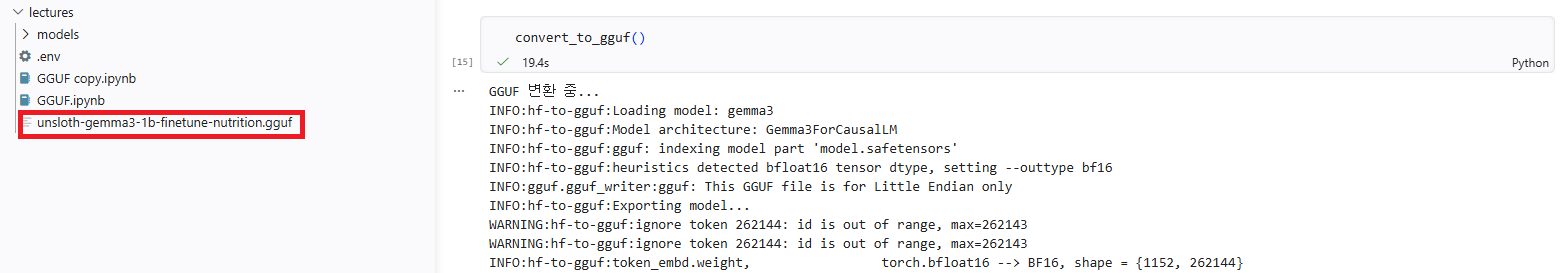

### 양자화 (용량 줄이기)

In [18]:
def quantize():
    print(f"양자화 중... ({QUANT_TYPE})")
    
    # cmake로 빌드 (make 대신)
    build_dir = os.path.join(LLAMA_CPP_DIR, "build")
    os.makedirs(build_dir, exist_ok=True)
    
    subprocess.run(["cmake", ".."], cwd=build_dir, check=True)
    subprocess.run(["cmake", "--build", ".", "--config", "Release"], cwd=build_dir, check=True)
    
    # 빌드된 바이너리 경로
    quantize_bin = os.path.join(build_dir, "bin", "llama-quantize")
    
    subprocess.run(
        [quantize_bin, OUTPUT_GGUF, QUANTIZED_GGUF, QUANT_TYPE],
        check=True
    )
    print(f"양자화 완료: {QUANTIZED_GGUF}")

In [19]:
quantize()

양자화 중... (Q4_K_M)


CMAKE_BUILD_TYPE=Release


-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU backend
-- x86 detected
-- Adding CPU backend variant ggml-cpu: -march=native 
-- ggml version: 0.9.11
-- ggml commit:  c5ce4bc22-dirty
-- OpenSSL found: 3.0.2
-- Generating embedded license file for target: common
-- Configuring done
-- Generating done
-- Build files have been written to: /opt/llama.cpp/build
Consolidate compiler generated dependencies of target ggml-base
[  0%] Building C object ggml/src/CMakeFiles/ggml-base.dir/ggml.c.o
[  1%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml.cpp.o
[  1%] Building C object ggml/src/CMakeFiles/ggml-base.dir/ggml-alloc.c.o
[  1%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-backend.cpp.o
[  1%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-opt.cpp.o
[  2%] Building CXX object ggml/src/CMakeFiles/ggml-base

main: build = 8702 (c5ce4bc22)
main: built with GNU 11.4.0 for Linux x86_64
main: quantizing './unsloth-gemma3-1b-finetune-nutrition.gguf' to './unsloth-gemma3-1b-finetune-nutrition_q4km.gguf' as Q4_K_M
llama_model_loader: loaded meta data with 32 key-value pairs and 340 tensors from ./unsloth-gemma3-1b-finetune-nutrition.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = gemma3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Gemma3
llama_model_loader: - kv   3:                         general.size_label str              = 1000M
llama_model_loader: - kv   4:                         gemma3.block_count u32              = 26
llama_model_loader: - kv   5:                      gemma3


main: quantize time =  8991.01 ms
main:    total time =  8991.01 ms
양자화 완료: ./unsloth-gemma3-1b-finetune-nutrition_q4km.gguf


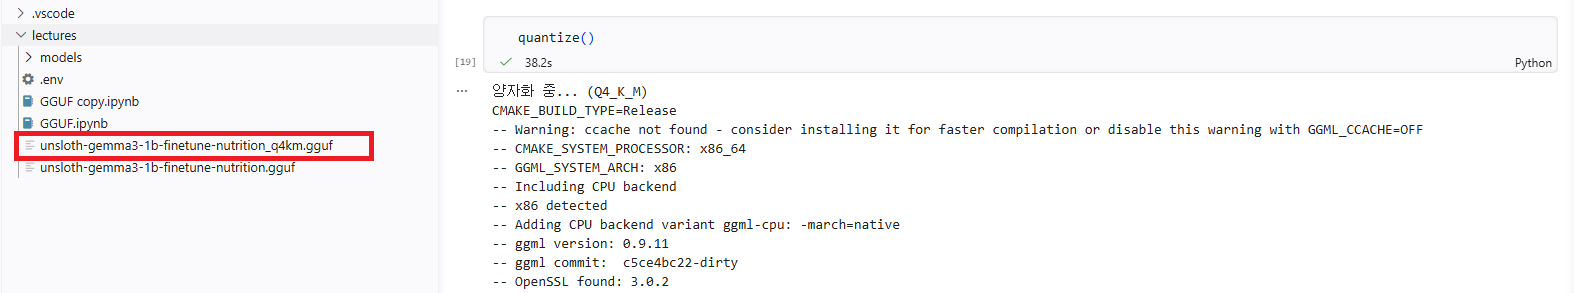

## HuggingFace 업로드

### 기존 레포지토리 삭제 

In [20]:
from huggingface_hub import HfApi

# API 인스턴스 생성
api = HfApi()

# 사용자의 Hugging Face 계정 ID
huggingface_id = "good593"
new_repo_id = f"{huggingface_id}/gemma3-finetune-diseases-gguf"

try:
    
    # 지정된 저장소를 완전히 삭제
    api.delete_repo(repo_id=new_repo_id)
    print("삭제가 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("삭제할 대상이 없습니다.")

삭제가 완료되었습니다.


### 수동 업로드

In [21]:
try:
    
    # 지정된 저장소를 생성
    api.create_repo(repo_id=new_repo_id)
    print("생성이 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("생성할 대상이 없습니다.")

생성이 완료되었습니다.


In [22]:
QUANTIZED_GGUF

'./unsloth-gemma3-1b-finetune-nutrition_q4km.gguf'

In [23]:
# 생성된 저장소에 파일 업로드 
api.upload_file(
    path_or_fileobj=QUANTIZED_GGUF,
    path_in_repo="unsloth-gemma3-1b-finetune-nutrition_q4km.gguf",
    repo_id=new_repo_id,
    repo_type="model"
)

Processing Files (1 / 1): 100%|██████████|  806MB /  806MB,  149MB/s  
New Data Upload: 100%|██████████|  479MB /  479MB, 88.7MB/s  


CommitInfo(commit_url='https://huggingface.co/good593/gemma3-finetune-diseases-gguf/commit/9ca47bade0187489f233a9f1c8c7da7dc0463fa2', commit_message='Upload unsloth-gemma3-1b-finetune-nutrition_q4km.gguf with huggingface_hub', commit_description='', oid='9ca47bade0187489f233a9f1c8c7da7dc0463fa2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/good593/gemma3-finetune-diseases-gguf', endpoint='https://huggingface.co', repo_type='model', repo_id='good593/gemma3-finetune-diseases-gguf'), pr_revision=None, pr_num=None)

### [hugging face 확인](https://huggingface.co/good593/gemma3-finetune-diseases-gguf)

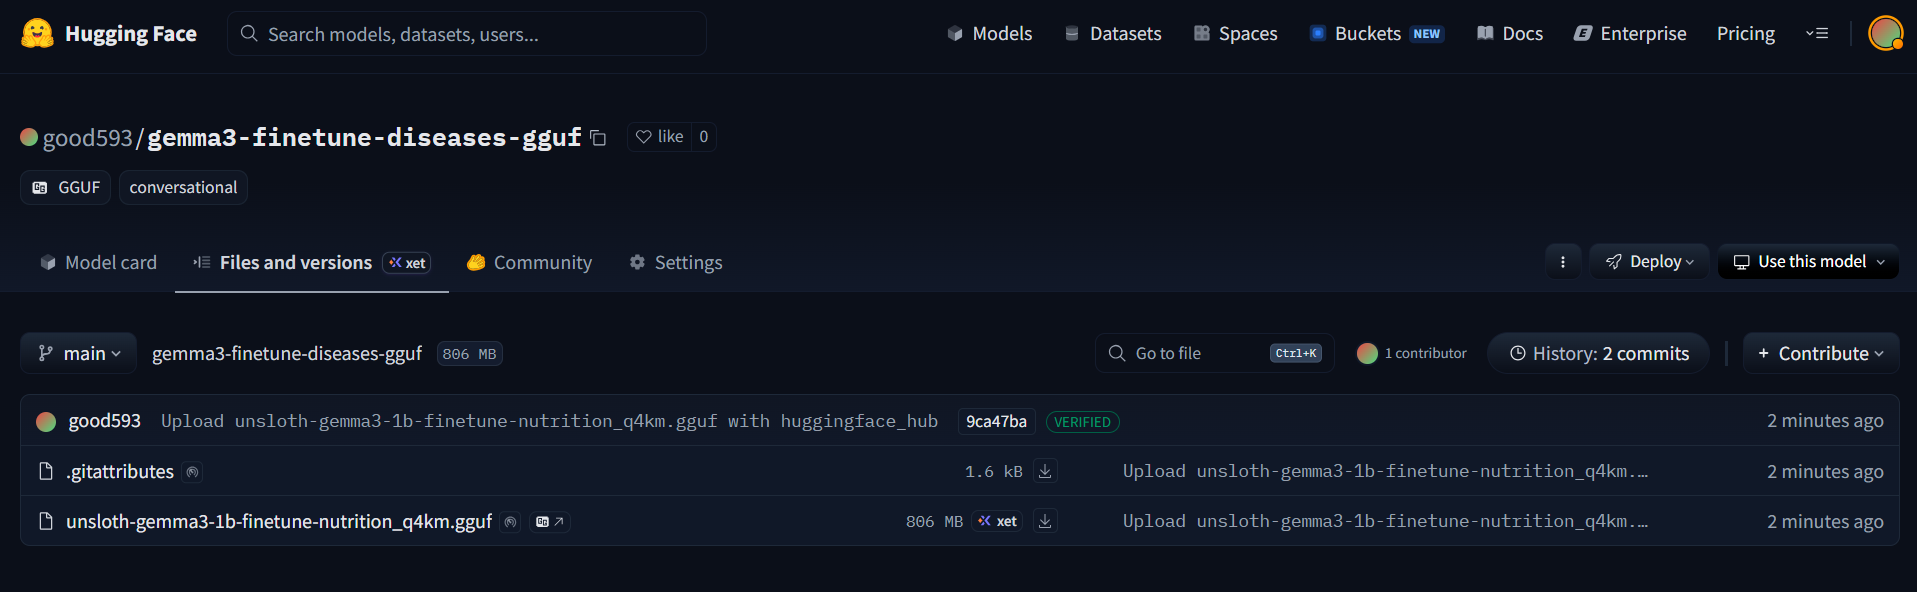